In [3]:
# Regular Python library imports 
import xarray as xr 
import numpy as np
import pandas as pd
import pyproj
import scipy.interpolate
import matplotlib.pyplot as plt
import glob
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

# Helper functions for reading the data from the bucket and plotting
from utils.read_data_utils import read_IS2SITMOGR4, read_book_data
from utils.plotting_utils import static_winter_comparison_lineplot, staticArcticMaps, interactiveArcticMaps, compute_gridcell_winter_means, interactive_winter_comparison_lineplot # Plotting utils 
from extra_funcs import read_IS2SITMOGR4_SUMMER, regrid_ubris_to_is2, get_cs2is2_snow  
# Plotting dependencies
#%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl

# Remove warnings to improve display
import warnings 
warnings.filterwarnings('ignore') 

# Get the current working directory
current_directory = os.getcwd()

In [4]:
# Load the winter IS-2 thickness data from zarr/s3
IS2SITMOGR4_v3 = read_IS2SITMOGR4(data_type='zarr-s3', persist=True) 
# Get some IS2 map projection/domain info needed for later functions
out_proj = 'EPSG:3411'
mapProj = pyproj.Proj("+init=" + out_proj)

xIS2 = IS2SITMOGR4_v3.x.values
yIS2 = IS2SITMOGR4_v3.y.values
out_lons = IS2SITMOGR4_v3.longitude.values
out_lats = IS2SITMOGR4_v3.latitude.values

load zarr from S3 bucket
zarr_path: s3://icesat-2-sea-ice-us-west-2/IS2SITMOGR4_V3/IS2SITMOGR4_V3_201811-202404.zarr


In [5]:
# Get UBRIS/UIT CS-2 data
start_date_cs2 = "Oct 2018"
end_date_cs2 = "July 2021"
# NB: MS indicates a time frequency of start of the month
date_range_cs2 = pd.date_range(start=start_date_cs2, end=end_date_cs2, freq='MS') 

# Re-grid the UBRIS/UIT CS-2 data to the IS-2 grid
cs2_ubris = regrid_ubris_to_is2(mapProj, xIS2, yIS2, out_lons, out_lats, date_range_cs2,
                             dataPathCS2=current_directory+'/data/', dataset='uit_cryosat2_seaicethickness_nh_80km_v1p7.nc')

# Relabel the cs2_sea_ice_thickness_UBRIS variable to ice_thickness_cs2_ubris
cs2_ubris = cs2_ubris.rename({'cs2_sea_ice_thickness_UBRIS': 'ice_thickness_cs2_ubris'})


In [6]:
cs2is2_snow = xr.open_dataset('./data/uit_sit_biweekly_v2north_polarstereo_80km_20210107_v1.1.nc', decode_times=False)

In [8]:
cs2is2_snow.sea_ice_density

<xarray.DataArray 'sea_ice_density' (yc: 121, xc: 121)>
[14641 values with dtype=float64]
Dimensions without coordinates: yc, xc
Attributes:
    units:    kg m^-3
    comment:  estimated sea ice density

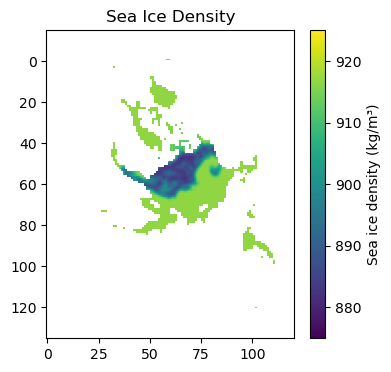

In [10]:
plt.figure(figsize=(4, 4))
plt.imshow(cs2is2_snow.sea_ice_density, 
          cmap='viridis',
          vmin=875,
          vmax=925)
plt.colorbar(label='Sea ice density (kg/m³)')
plt.title('Sea Ice Density')
plt.axis('equal')
plt.show()

In [12]:
cs2_ubris.cs2_sea_ice_density_UBRIS.isel(time=10)

<xarray.DataArray 'cs2_sea_ice_density_UBRIS' (y: 448, x: 304)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
    latitude   (y, x) float32 31.1 31.2 31.3 31.39 ... 34.78 34.68 34.58 34.47
    longitude  (y, x) float32 168.3 168.1 168.0 167.8 ... -10.36 -10.18 -9.999
  * x          (x) float32 -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y          (y) float32 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
    time       datetime64[ns] 2019-08-01

In [19]:
cs2_ubris.time.isel(time=27)

<xarray.DataArray 'time' ()>
array('2021-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2021-01-01

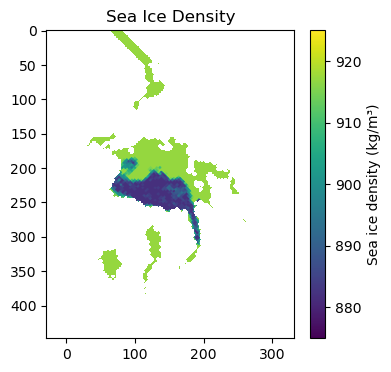

In [20]:
plt.figure(figsize=(4, 4))
plt.imshow(cs2_ubris.cs2_sea_ice_density_UBRIS.isel(time=27), 
          cmap='viridis',
          vmin=875,
          vmax=925)
plt.colorbar(label='Sea ice density (kg/m³)')
plt.title('Sea Ice Density')
plt.axis('equal')
plt.show()